# Full Boosted-Tree Comparison

This notebook compares XGBoost, LightGBM, and CatBoost using their default-ish settings, to see if boosting actually beats the baselines from the last notebook before spending time tuning any of them. Each outer fold uses its own inner split just to decide how many rounds to train for, so the outer validation data is never used for anything except the final score.


## Import libraries


In [3]:
from pathlib import Path
import gc
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    average_precision_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

try:
    import xgboost as xgb
    import lightgbm as lgb
    from catboost import CatBoostClassifier
except ImportError as error:
    raise ImportError(
        "Install required packages first: pip install xgboost lightgbm catboost"
    ) from error

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 150)
print("XGBoost version:", xgb.__version__)
print("LightGBM version:", lgb.__version__)
print("Libraries imported successfully.")

XGBoost version: 3.2.0
LightGBM version: 4.6.0
Libraries imported successfully.


## Set paths and experiment settings


In [5]:
current_folder = Path.cwd().resolve()
project_root = current_folder.parent if current_folder.name == "notebooks" else current_folder
dataset_path = project_root / "data" / "modeling" / "final_feature_dataset.pkl"
training_ids_path = project_root / "data" / "modeling" / "splits" / "training_ids.csv"
test_ids_path = project_root / "data" / "modeling" / "splits" / "test_ids.csv"
folds_path = project_root / "data" / "modeling" / "splits" / "training_fold_assignments.csv"
baseline_oof_path = project_root / "data" / "modeling" / "baseline_results" / "baseline_oof_predictions.pkl"
result_folder = project_root / "data" / "modeling" / "boosted_results"
figure_folder = project_root / "reports" / "figures"
audit_folder = project_root / "reports" / "audits"
for folder in [result_folder, figure_folder, audit_folder]:
    folder.mkdir(parents=True, exist_ok=True)
for path in [dataset_path, training_ids_path, test_ids_path, folds_path]:
    assert path.exists(), f"Required file missing: {path}"
RANDOM_STATE = 2026
EXPECTED_TRAINING_ROWS = 246008
EARLY_STOPPING_ROUNDS = 200
MAX_BOOSTING_ROUNDS = 5000
print("Maximum boosting rounds:", MAX_BOOSTING_ROUNDS)
print("Early-stopping patience:", EARLY_STOPPING_ROUNDS)

Maximum boosting rounds: 5000
Early-stopping patience: 200


## Load the complete training data


In [7]:
full_data = pd.read_pickle(dataset_path)
training_ids = pd.read_csv(training_ids_path)["SK_ID_CURR"]
test_ids = pd.read_csv(test_ids_path)["SK_ID_CURR"]
fold_assignments = pd.read_csv(folds_path)
training_id_set = set(training_ids)
test_id_set = set(test_ids)
training_data = full_data.loc[full_data["SK_ID_CURR"].isin(training_id_set)].copy()
training_data = training_data.merge(fold_assignments, on="SK_ID_CURR", how="left", validate="one_to_one")
assert len(training_data) == EXPECTED_TRAINING_ROWS
assert training_data["FOLD"].nunique() == 5
assert not training_data["SK_ID_CURR"].isin(test_id_set).any()
print("Training rows:", len(training_data))
print("Final test rows excluded:", len(test_ids))
print("Default rate:", round(training_data["TARGET"].mean(), 5))

Training rows: 246008
Final test rows excluded: 61503
Default rate: 0.08073


Same training data and folds as the baseline notebook.


## Define predictors and fold-fitted preprocessing


In [10]:
excluded_columns = ["SK_ID_CURR", "TARGET", "FOLD", "CODE_GENDER"]
predictor_columns = [c for c in training_data.columns if c not in excluded_columns]
categorical_columns = training_data[predictor_columns].select_dtypes(exclude="number").columns.tolist()
numerical_columns = [c for c in predictor_columns if c not in categorical_columns]
X = training_data[predictor_columns].copy()
y = training_data["TARGET"].astype("int8").copy()
folds = training_data["FOLD"].astype(int).copy()
for column in categorical_columns:
    X[column] = X[column].astype("object")

def make_preprocessor():
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ])
    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value", unknown_value=-1,
            encoded_missing_value=-2, dtype=np.float32
        )),
    ])
    return ColumnTransformer([
        ("numeric", numeric_pipeline, numerical_columns),
        ("categorical", categorical_pipeline, categorical_columns),
    ], sparse_threshold=0.0)

print("Predictors used:", len(predictor_columns))
print("Numerical predictors:", len(numerical_columns))
print("Categorical predictors:", len(categorical_columns))

Predictors used: 330
Numerical predictors: 318
Categorical predictors: 12


Same 330 predictors as before, but categorical columns are ordinal-encoded here instead of one-hot encoded, since tree models handle that better than linear models do.


## Define model builders


In [13]:
def build_xgboost(n_estimators, early_stopping=False):
    return xgb.XGBClassifier(
        n_estimators=n_estimators, learning_rate=0.03, max_depth=6,
        min_child_weight=5, gamma=0, subsample=1.0, colsample_bytree=0.90,
        reg_alpha=0.10, reg_lambda=5.0, objective="binary:logistic",
        eval_metric="auc", tree_method="hist", max_bin=255,
        n_jobs=-1, random_state=RANDOM_STATE,
        early_stopping_rounds=EARLY_STOPPING_ROUNDS if early_stopping else None,
    )

def build_lightgbm(n_estimators):
    return lgb.LGBMClassifier(
        n_estimators=n_estimators, learning_rate=0.03, num_leaves=31,
        max_depth=-1, min_child_samples=40, subsample=1.0,
        colsample_bytree=0.90, reg_alpha=0.10, reg_lambda=5.0,
        objective="binary", n_jobs=-1, random_state=RANDOM_STATE, verbosity=-1,
    )

def build_catboost(iterations):
    return CatBoostClassifier(
        iterations=iterations, learning_rate=0.03, depth=7,
        l2_leaf_reg=5.0, loss_function="Logloss", eval_metric="AUC",
        random_seed=RANDOM_STATE, thread_count=-1, verbose=False,
        allow_writing_files=False,
    )

model_names = ["xgboost", "lightgbm", "catboost"]
print("Models configured:", model_names)

Models configured: ['xgboost', 'lightgbm', 'catboost']


Starting configurations for all three model types, similar depth and learning rate, nothing tuned yet. Early stopping is used to avoid manually guessing how many rounds each one needs.


## Evaluation function


In [16]:
def calculate_metrics(y_true, probability):
    return {
        "roc_auc": roc_auc_score(y_true, probability),
        "pr_auc": average_precision_score(y_true, probability),
    }

print("Evaluation function created.")

Evaluation function created.


Just ROC-AUC and PR-AUC here, since that's what's being compared across models at this stage.


## Run nested early stopping and full outer-fold refitting


In [19]:
oof_predictions = pd.DataFrame({
    "SK_ID_CURR": training_data["SK_ID_CURR"].to_numpy(),
    "TARGET": y.to_numpy(),
    "FOLD": folds.to_numpy(),
})
for model_name in model_names:
    oof_predictions[model_name] = np.nan
fold_rows = []
iteration_rows = []

for fold_number in sorted(folds.unique()):
    print(f"\nOUTER FOLD {fold_number}")
    outer_train_mask = folds.ne(fold_number)
    outer_valid_mask = folds.eq(fold_number)
    outer_train_indices = np.flatnonzero(outer_train_mask.to_numpy())
    outer_valid_indices = np.flatnonzero(outer_valid_mask.to_numpy())
    inner_train_indices, inner_valid_indices = train_test_split(
        outer_train_indices, test_size=0.10, stratify=y.iloc[outer_train_indices],
        random_state=RANDOM_STATE + int(fold_number)
    )

    inner_preprocessor = make_preprocessor()
    X_inner_train = inner_preprocessor.fit_transform(X.iloc[inner_train_indices]).astype("float32")
    X_inner_valid = inner_preprocessor.transform(X.iloc[inner_valid_indices]).astype("float32")
    y_inner_train = y.iloc[inner_train_indices]
    y_inner_valid = y.iloc[inner_valid_indices]

    selected_iterations = {}
    xgb_search = build_xgboost(MAX_BOOSTING_ROUNDS, early_stopping=True)
    xgb_search.fit(X_inner_train, y_inner_train, eval_set=[(X_inner_valid, y_inner_valid)], verbose=False)
    selected_iterations["xgboost"] = int(xgb_search.best_iteration) + 1

    lgb_search = build_lightgbm(MAX_BOOSTING_ROUNDS)
    lgb_search.fit(
        X_inner_train, y_inner_train, eval_set=[(X_inner_valid, y_inner_valid)],
        eval_metric="auc", callbacks=[
            lgb.early_stopping(EARLY_STOPPING_ROUNDS, verbose=False), lgb.log_evaluation(0)
        ]
    )
    selected_iterations["lightgbm"] = int(lgb_search.best_iteration_)

    cat_search = build_catboost(MAX_BOOSTING_ROUNDS)
    cat_search.fit(
        X_inner_train, y_inner_train, eval_set=(X_inner_valid, y_inner_valid),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS, verbose=False
    )
    selected_iterations["catboost"] = int(cat_search.get_best_iteration()) + 1
    print("  Selected iterations:", selected_iterations)

    del inner_preprocessor, X_inner_train, X_inner_valid, y_inner_train, y_inner_valid
    del xgb_search, lgb_search, cat_search
    gc.collect()

    outer_preprocessor = make_preprocessor()
    X_outer_train = outer_preprocessor.fit_transform(X.iloc[outer_train_indices]).astype("float32")
    X_outer_valid = outer_preprocessor.transform(X.iloc[outer_valid_indices]).astype("float32")
    y_outer_train = y.iloc[outer_train_indices]
    y_outer_valid = y.iloc[outer_valid_indices]

    final_models = {
        "xgboost": build_xgboost(selected_iterations["xgboost"], early_stopping=False),
        "lightgbm": build_lightgbm(selected_iterations["lightgbm"]),
        "catboost": build_catboost(selected_iterations["catboost"]),
    }
    for model_name, model in final_models.items():
        start_time = time.time()
        model.fit(X_outer_train, y_outer_train, verbose=False) if model_name in ["xgboost", "catboost"] else model.fit(X_outer_train, y_outer_train)
        probability = model.predict_proba(X_outer_valid)[:, 1]
        elapsed_minutes = (time.time() - start_time) / 60
        oof_predictions.loc[outer_valid_mask, model_name] = probability
        metrics = calculate_metrics(y_outer_valid, probability)
        metrics.update({
            "model": model_name, "fold": int(fold_number),
            "selected_iterations": selected_iterations[model_name],
            "outer_train_rows": len(outer_train_indices),
            "outer_validation_rows": len(outer_valid_indices),
            "training_minutes": elapsed_minutes,
        })
        fold_rows.append(metrics)
        iteration_rows.append({
            "model": model_name, "fold": int(fold_number),
            "selected_iterations": selected_iterations[model_name]
        })
        print(f"  {model_name}: AUC={metrics['roc_auc']:.5f}, PR AUC={metrics['pr_auc']:.5f}, minutes={elapsed_minutes:.2f}")

    del outer_preprocessor, X_outer_train, X_outer_valid, y_outer_train, y_outer_valid, final_models
    gc.collect()

fold_metrics = pd.DataFrame(fold_rows)
selected_iteration_table = pd.DataFrame(iteration_rows)
print("\nAll nested five-fold boosted-tree training completed.")


OUTER FOLD 1
  Selected iterations: {'xgboost': 746, 'lightgbm': 893, 'catboost': 2579}
  xgboost: AUC=0.78916, PR AUC=0.28185, minutes=0.36


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lightgbm: AUC=0.78961, PR AUC=0.28199, minutes=0.33
  catboost: AUC=0.78902, PR AUC=0.28023, minutes=2.40

OUTER FOLD 2
  Selected iterations: {'xgboost': 978, 'lightgbm': 757, 'catboost': 2484}
  xgboost: AUC=0.79015, PR AUC=0.28163, minutes=0.50


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lightgbm: AUC=0.79000, PR AUC=0.28437, minutes=0.33
  catboost: AUC=0.78996, PR AUC=0.28424, minutes=2.39

OUTER FOLD 3
  Selected iterations: {'xgboost': 889, 'lightgbm': 935, 'catboost': 2610}
  xgboost: AUC=0.78117, PR AUC=0.27521, minutes=0.56


...

  lightgbm: AUC=0.78055, PR AUC=0.27558, minutes=0.46
  catboost: AUC=0.78357, PR AUC=0.27992, minutes=3.47

OUTER FOLD 4
  Selected iterations: {'xgboost': 682, 'lightgbm': 798, 'catboost': 1946}
  xgboost: AUC=0.78803, PR AUC=0.27646, minutes=0.47


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lightgbm: AUC=0.78757, PR AUC=0.27653, minutes=0.39
  catboost: AUC=0.78776, PR AUC=0.27369, minutes=2.18

OUTER FOLD 5
  Selected iterations: {'xgboost': 682, 'lightgbm': 877, 'catboost': 2288}
  xgboost: AUC=0.78925, PR AUC=0.28273, minutes=0.49


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


  lightgbm: AUC=0.78956, PR AUC=0.28284, minutes=0.42
  catboost: AUC=0.78883, PR AUC=0.28503, minutes=2.59

All nested five-fold boosted-tree training completed.


For each outer fold, a small slice of the training data (10%) is held back just to decide how many boosting rounds to use, then the model is refit on the full outer-training data with that round count. This keeps the actual validation fold completely untouched during tuning, so there's no leakage from using it twice.


## Calculate overall OOF results


In [22]:
overall_rows = []
for model_name in model_names:
    metrics = calculate_metrics(oof_predictions["TARGET"], oof_predictions[model_name])
    model_folds = fold_metrics.loc[fold_metrics["model"].eq(model_name)]
    metrics.update({
        "model": model_name,
        "fold_auc_mean": model_folds["roc_auc"].mean(),
        "fold_auc_std": model_folds["roc_auc"].std(),
        "fold_pr_auc_mean": model_folds["pr_auc"].mean(),
        "mean_selected_iterations": model_folds["selected_iterations"].mean(),
        "total_refit_minutes": model_folds["training_minutes"].sum(),
    })
    overall_rows.append(metrics)
overall_metrics = pd.DataFrame(overall_rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
overall_metrics.round(5)

,roc_auc,pr_auc,model,fold_auc_mean,fold_auc_std,fold_pr_auc_mean,mean_selected_iterations,total_refit_minutes
0,0.78780,0.28025,catboost,0.78783,0.00250,0.28062,2381.4,13.02304
1,0.78752,0.27900,xgboost,0.78755,0.00365,0.27958,795.4,2.37786
2,0.78742,0.27963,lightgbm,0.78746,0.00398,0.28026,852.0,1.92746


CatBoost comes out slightly ahead here, but all three are close. This is just the starting point, each one gets tuned separately in the next few notebooks to see if that changes.


## Compare with the valid baseline models


In [25]:
comparison_rows = overall_metrics[["model", "roc_auc", "pr_auc"]].copy()
if baseline_oof_path.exists():
    baseline_oof = pd.read_pickle(baseline_oof_path)
    baseline_columns = [c for c in ["logistic_unweighted", "random_forest_balanced"] if c in baseline_oof.columns]
    for model_name in baseline_columns:
        row = calculate_metrics(baseline_oof["TARGET"], baseline_oof[model_name])
        row["model"] = model_name
        comparison_rows = pd.concat([comparison_rows, pd.DataFrame([row])], ignore_index=True)
comparison_rows = comparison_rows.sort_values("roc_auc", ascending=False).reset_index(drop=True)
comparison_rows.round(5)

,model,roc_auc,pr_auc
0,catboost,0.78780,0.28025
1,xgboost,0.78752,0.27900
2,lightgbm,0.78742,0.27963
3,logistic_unweighted,0.77582,0.26276
4,random_forest_balanced,0.76877,0.25479


All three boosted models clearly beat both baselines from the previous notebook, confirming boosting is worth pursuing further.


## Plot OOF curves


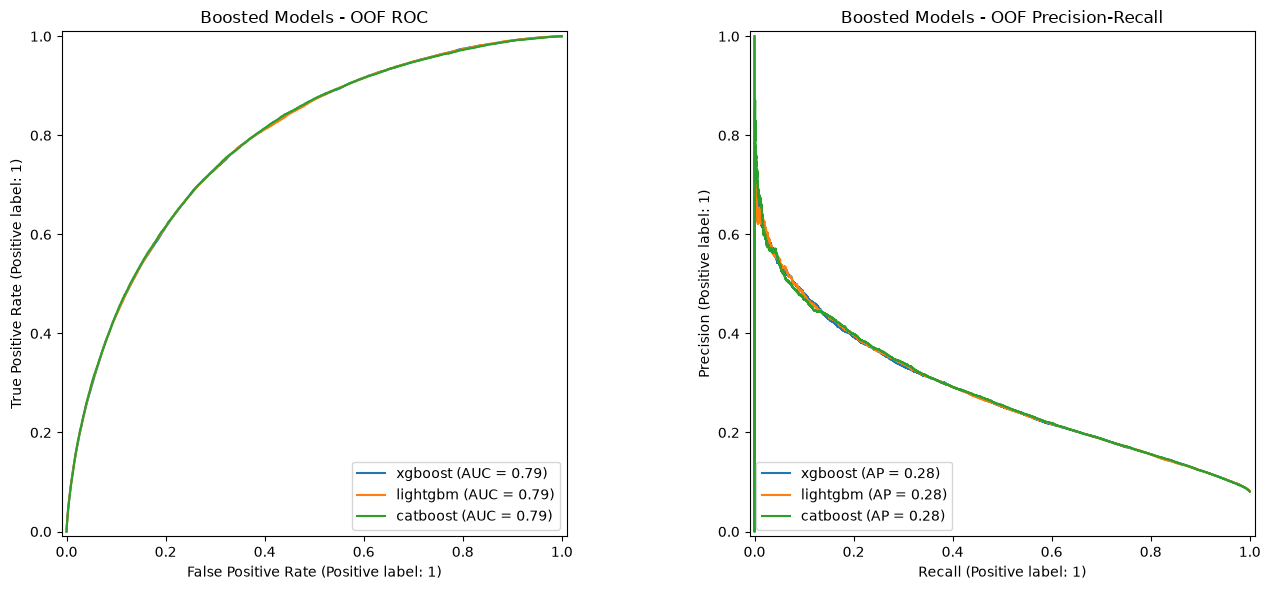

Figure saved: /Users/taranveersingh/A-MRP/reports/figures/boosted_model_oof_curves.png


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for model_name in model_names:
    RocCurveDisplay.from_predictions(oof_predictions["TARGET"], oof_predictions[model_name], name=model_name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(oof_predictions["TARGET"], oof_predictions[model_name], name=model_name, ax=axes[1])
axes[0].set_title("Boosted Models - OOF ROC")
axes[1].set_title("Boosted Models - OOF Precision-Recall")
fig.tight_layout()
figure_path = figure_folder / "boosted_model_oof_curves.png"
fig.savefig(figure_path, dpi=160, bbox_inches="tight")
plt.show()
print("Figure saved:", figure_path)

Same idea as before, one curve per model, useful for a quick visual check that they're all performing similarly.


## Validate and save results


In [31]:
validation_checks = pd.DataFrame([
    {"check": "Complete training dataset used", "passed": len(X) == EXPECTED_TRAINING_ROWS},
    {"check": "All models used all five outer folds", "passed": fold_metrics.groupby("model")["fold"].nunique().eq(5).all()},
    {"check": "All OOF predictions complete", "passed": not oof_predictions[model_names].isna().any().any()},
    {"check": "One OOF row per training applicant", "passed": len(oof_predictions) == EXPECTED_TRAINING_ROWS and oof_predictions["SK_ID_CURR"].is_unique},
    {"check": "Final test excluded", "passed": not oof_predictions["SK_ID_CURR"].isin(test_id_set).any()},
    {"check": "Protected gender excluded", "passed": "CODE_GENDER" not in predictor_columns},
    {"check": "Selected iterations valid", "passed": selected_iteration_table["selected_iterations"].between(1, MAX_BOOSTING_ROUNDS).all()},
    {"check": "No outer-fold row sampling", "passed": fold_metrics["outer_train_rows"].add(fold_metrics["outer_validation_rows"]).eq(EXPECTED_TRAINING_ROWS).all()},
    {"check": "Metrics finite", "passed": np.isfinite(overall_metrics.select_dtypes(include="number").to_numpy()).all()},
])
assert validation_checks["passed"].all(), "At least one boosted-tree experiment check failed."
oof_predictions.to_pickle(result_folder / "boosted_oof_predictions.pkl")
oof_predictions.to_csv(result_folder / "boosted_oof_predictions.csv", index=False)
fold_metrics.to_csv(result_folder / "boosted_fold_metrics.csv", index=False)
overall_metrics.to_csv(result_folder / "boosted_overall_metrics.csv", index=False)
selected_iteration_table.to_csv(result_folder / "boosted_selected_iterations.csv", index=False)
comparison_rows.to_csv(result_folder / "boosted_and_baseline_comparison.csv", index=False)
validation_checks.to_csv(audit_folder / "boosted_model_experiment_validation.csv", index=False)
pd.DataFrame({"predictor": predictor_columns}).to_csv(result_folder / "boosted_predictor_list.csv", index=False)
display(validation_checks)
print("Results saved in:", result_folder)
print("Best boosted model:", overall_metrics.iloc[0]["model"])
print("Best boosted OOF ROC AUC:", round(overall_metrics.iloc[0]["roc_auc"], 6))
print("Final test evaluations performed: 0")

,check,passed
0,Complete training dataset used,True
1,All models used all five outer folds,True
2,All OOF predictions complete,True
3,One OOF row per training applicant,True
4,Final test excluded,True
5,Protected gender excluded,True
6,Selected iterations valid,True
7,No outer-fold row sampling,True
8,Metrics finite,True


Results saved in: /Users/taranveersingh/A-MRP/data/modeling/boosted_results
Best boosted model: catboost
Best boosted OOF ROC AUC: 0.787805
Final test evaluations performed: 0


All checks passed.


## Main results

All three boosted models landed close together (ROC-AUC around 0.787-0.788), with CatBoost coming out slightly ahead. All three clearly beat the best baseline from the last notebook (logistic regression at 0.7758), which justifies moving on to tuning them individually.

The next three notebooks tune each of these model types separately.
